# Time Series Analysis for Malaysia Residential Property Data (Pahang)

In [144]:
# Time Series Analysis for Malaysia Residential Property Data (Pahang)

# Basic data manipulation and analysis
import pandas as pd
import numpy as np
import itertools  # For grid search parameter combinations

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Machine Learning models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

# Time Series specific libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Try to import Prophet (may not be installed)
try:
    from prophet import Prophet
    PROPHET_AVAILABLE = True
except ImportError:
    PROPHET_AVAILABLE = False
    print("Prophet not available. Install with: pip install prophet")

# Time series cross-validation
from sklearn.model_selection import TimeSeriesSplit

# Warning suppression
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [145]:
df = pd.read_csv('Malaysia Residential Property Data.csv', sep='\t', encoding='utf-8')

In [146]:
df.head()

,Property Type,District,Mukim,Scheme Name/Area,Road Name,"Month, Year of Transaction Date",Tenure,Land/Parcel Area,Unit,Main Floor Area,Unit,Unit Level,Transaction Price,Unnamed: 13
0,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Bdr Masjid Tanah,TMN BUKIT INDAH FASA 2,JLN BUKIT INDAH 6,March 2024,Freehold,374.00,sq.m,106,sq.m,,"RM470,000.00",NaN
1,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN BELIMBING HARMONI,JLN BELIMBING HARMONI,May 2023,Leasehold,234.00,sq.m,67,sq.m,,"RM483,000.00",NaN
2,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM359,000.00",NaN
3,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,268.00,sq.m,118,sq.m,,"RM435,000.00",NaN
4,1 - 1 1/2 Storey Semi-Detached,Alor Gajah,Belimbing,TMN VISTA BELIMBING,JALAN DURIAN TUNGGAL-ALOR GAJAH,April 2021,Freehold,297.00,sq.m,118,sq.m,,"RM373,000.00",NaN


In [147]:

df.dtypes

Property Type                          str
District                               str
Mukim                                  str
Scheme Name/Area                       str
Road Name                              str
Month, Year of Transaction Date        str
Tenure                                 str
Land/Parcel Area                       str
Unit                                   str
Main Floor Area                        str
Unit                                   str
Unit Level                             str
Transaction Price                      str
Unnamed: 13                        float64
dtype: object

In [148]:
df.shape

(410959, 14)

<Axes: >

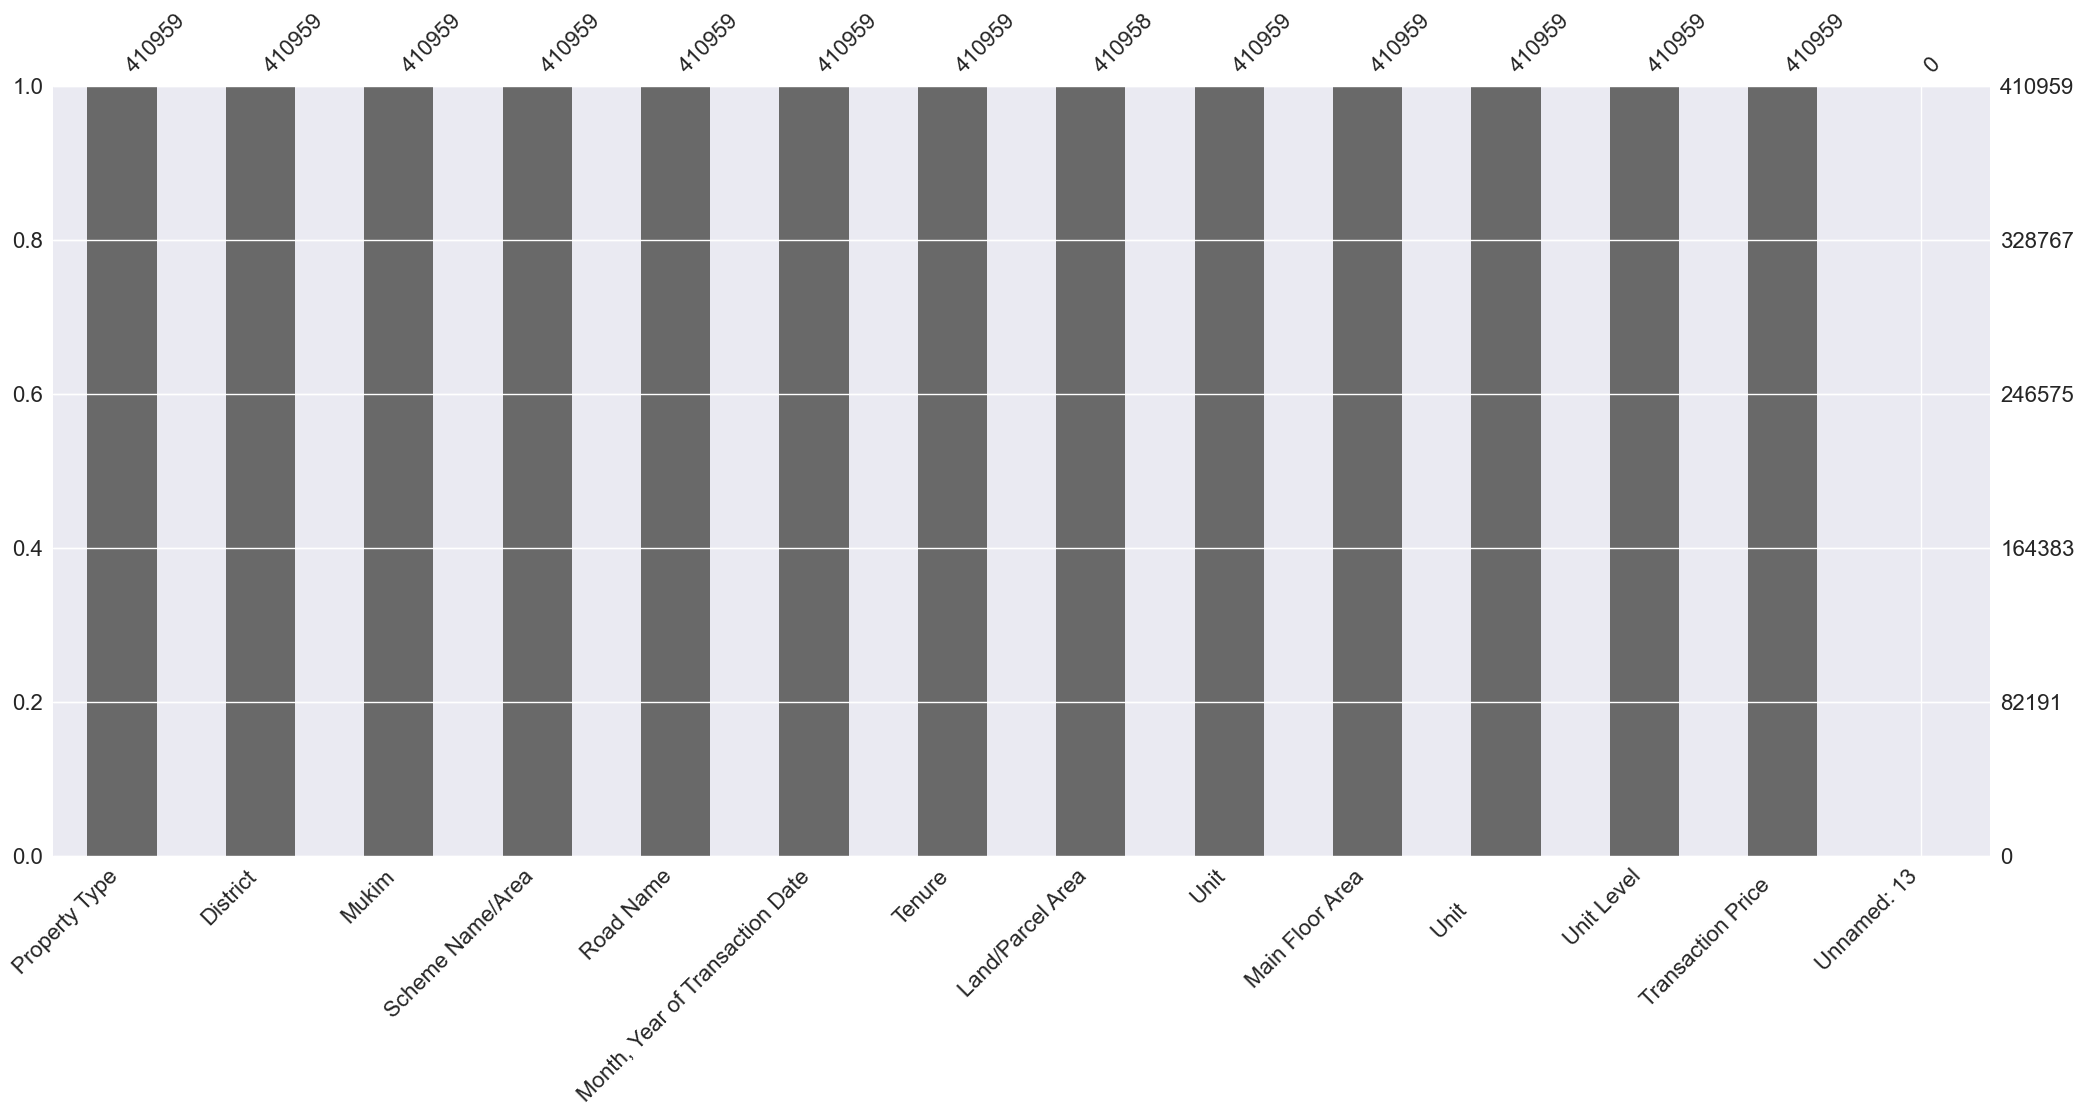

In [149]:
msno.bar(df) 

In [150]:
print("\nExisting column :\n " + f"{df.columns.tolist()}") # inspect column name, view any whitespace


Existing column :
 ['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit        ', 'Unit Level', 'Transaction Price  ', 'Unnamed: 13']


In [151]:

df.duplicated().sum() # total count of duplicate rows present in the DataFrame:

np.int64(447)

In [152]:
for i in df.columns: # checking total null values/NaN in a column
    print(i," : ",df[i].isnull().sum()) # OR print(i," : ",df[i].isna().sum())

Property Type  :  0
District  :  0
Mukim  :  0
Scheme Name/Area  :  0
Road Name  :  0
Month, Year of Transaction Date  :  0
Tenure  :  0
Land/Parcel Area  :  1
Unit  :  0
Main Floor Area  :  0
Unit          :  0
Unit Level  :  0
Transaction Price    :  0
Unnamed: 13  :  410959


**Data wrangling**

In [153]:

df.columns = df.columns.str.strip() # remove leading/trailing spaces in column names and print the output after column stripped
print("\nColumn after stripped :\n" + f"{df.columns.tolist()}\n")


Column after stripped :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price', 'Unnamed: 13']



In [154]:
df = df.dropna(axis=1, how='all') # remove the entire column only if all values are NaN and print the output after removed NaN column:
print("\nResult after remove NaN column :\n"+ f"{df.columns.tolist()}")


Result after remove NaN column :
['Property Type', 'District', 'Mukim', 'Scheme Name/Area', 'Road Name', 'Month, Year of Transaction Date', 'Tenure', 'Land/Parcel Area', 'Unit', 'Main Floor Area', 'Unit', 'Unit Level', 'Transaction Price']


In [155]:
# Clean and convert 'Transaction Price' to numeric
df['Transaction Price'] = df['Transaction Price'].str.replace('RM', '', regex=False)
df['Transaction Price'] = df['Transaction Price'].str.replace(',', '', regex=False).astype(float)

print(df['Land/Parcel Area'].unique())
print(df['Land/Parcel Area'][df['Land/Parcel Area'] == ''])  # find empty strings

# Clean and convert 'Land/Parcel Area' to numeric
df['Land/Parcel Area'] = df['Land/Parcel Area'].str.replace(',', '', regex=False).astype(float)

print(df['Main Floor Area'].unique())
print(df['Main Floor Area'][df['Main Floor Area'] == ''])  # find empty strings

# Clean and convert 'Main Floor Area' to numeric
df['Main Floor Area'] = df['Main Floor Area'].str.replace('-', '', regex=False)
df['Main Floor Area'] = df['Main Floor Area'].str.replace(',', '', regex=False).replace('', np.nan).astype(float)

<StringArray>
['374.00', '234.00', '268.00', '297.00', '331.00', '387.00', '478.00',
 '490.00', '433.00', '290.00',
 ...
 '150.31',  '97.63',  '96.52',  '96.53',  '99.86',  '81.70',  '90.81',
 '132.28',  '70.29', '359.63']
Length: 17613, dtype: str
Series([], Name: Land/Parcel Area, dtype: str)
<StringArray>
[  '106',    '67',   '118',   '116',   '217',   '143',    '82',   '133',
   '117',    '93',
 ...
   '630', '1,360',   '661', '2,178', '1,755',   '707',   '610',   '561',
 '1,823',    '23']
Length: 825, dtype: str
Series([], Name: Main Floor Area, dtype: str)


In [156]:
# Convert 'Month, Year of Transaction Date' to datetime
df['Transaction Date'] = pd.to_datetime(df['Month, Year of Transaction Date'], format='%B %Y')

**Analayze data after data wrangling**

In [157]:

df.dtypes

Property Type                                 str
District                                      str
Mukim                                         str
Scheme Name/Area                              str
Road Name                                     str
Month, Year of Transaction Date               str
Tenure                                        str
Land/Parcel Area                          float64
Unit                                          str
Main Floor Area                           float64
Unit                                          str
Unit Level                                    str
Transaction Price                         float64
Transaction Date                   datetime64[us]
dtype: object

<Axes: >

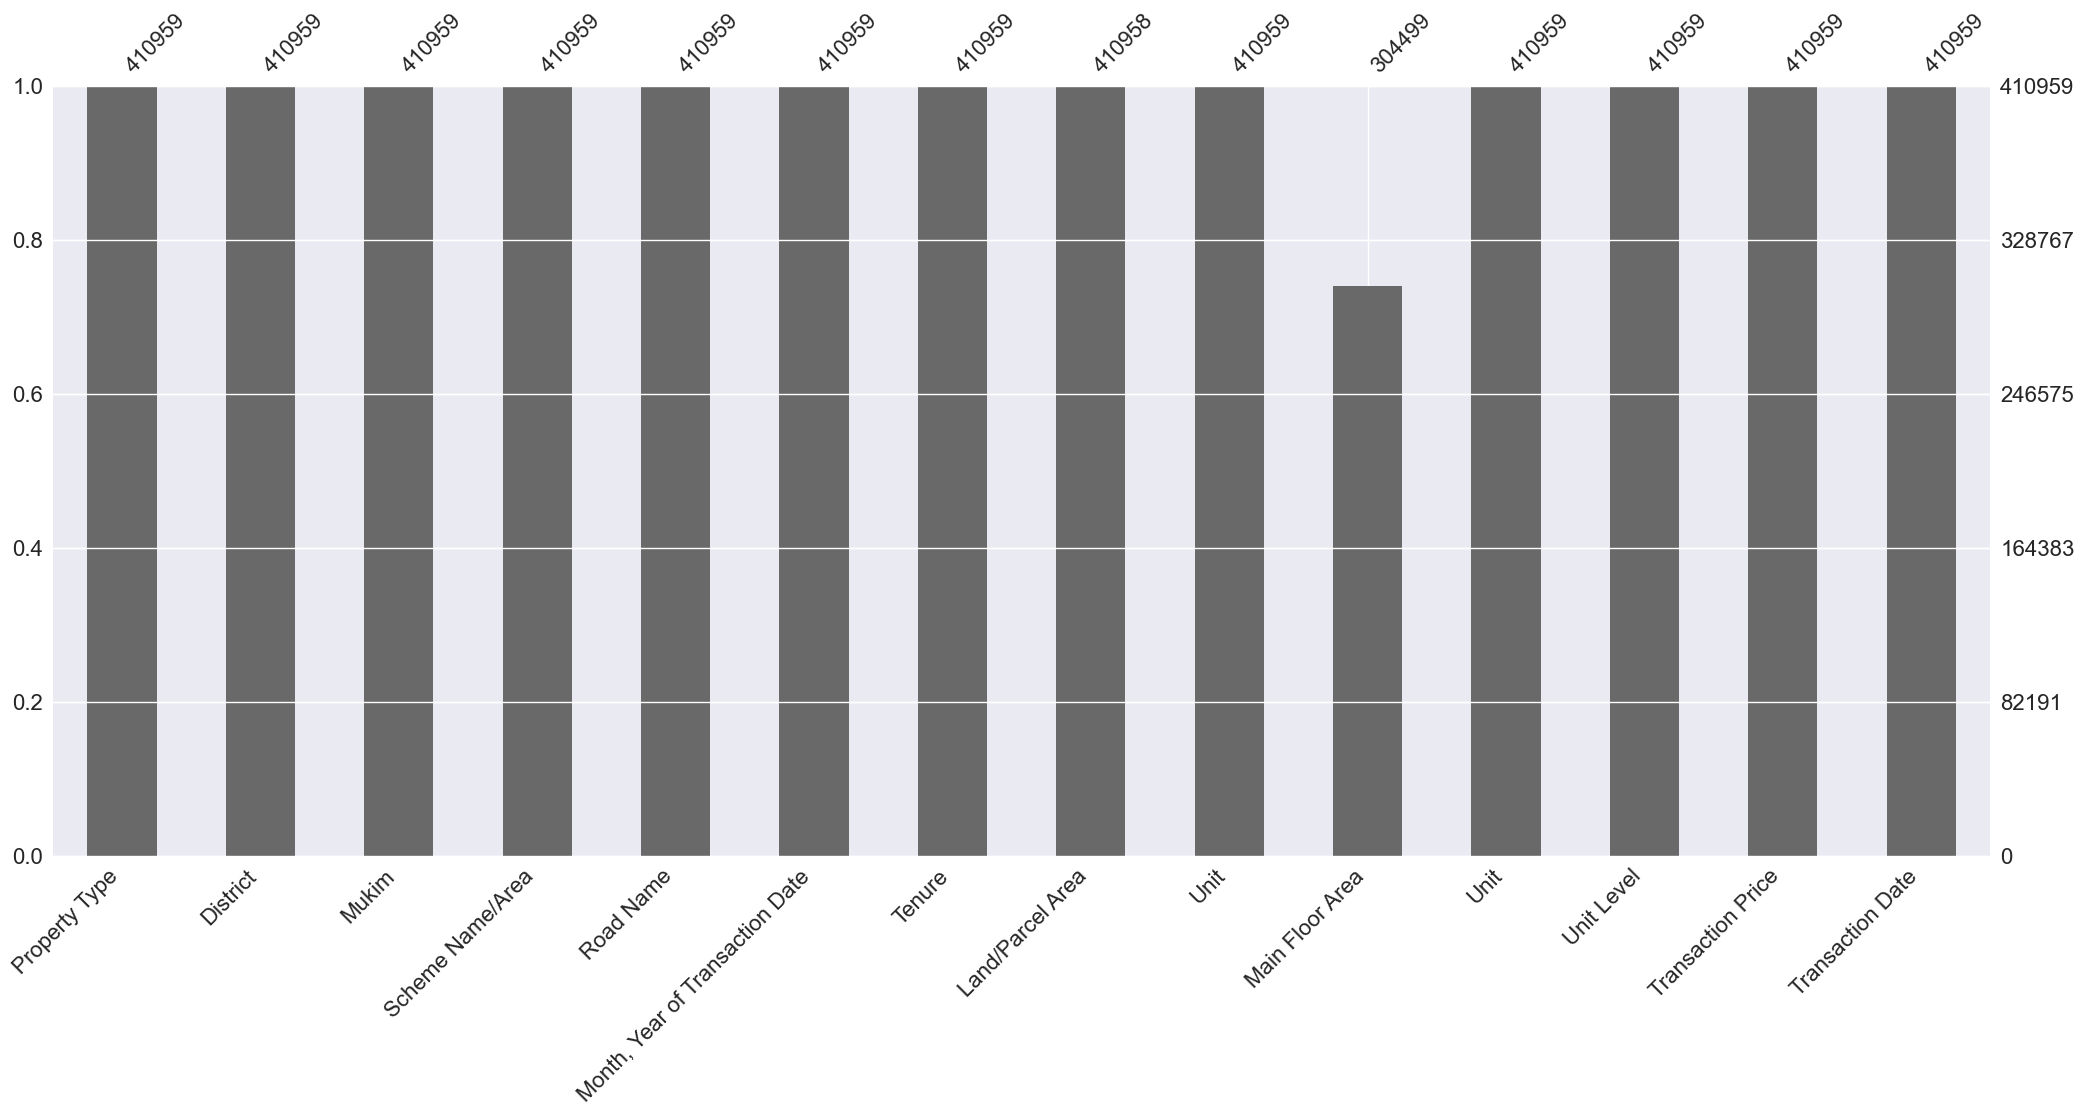

In [158]:
msno.bar(df) # visualizing missing numeric data with bar chart (missingno library)

<Axes: >

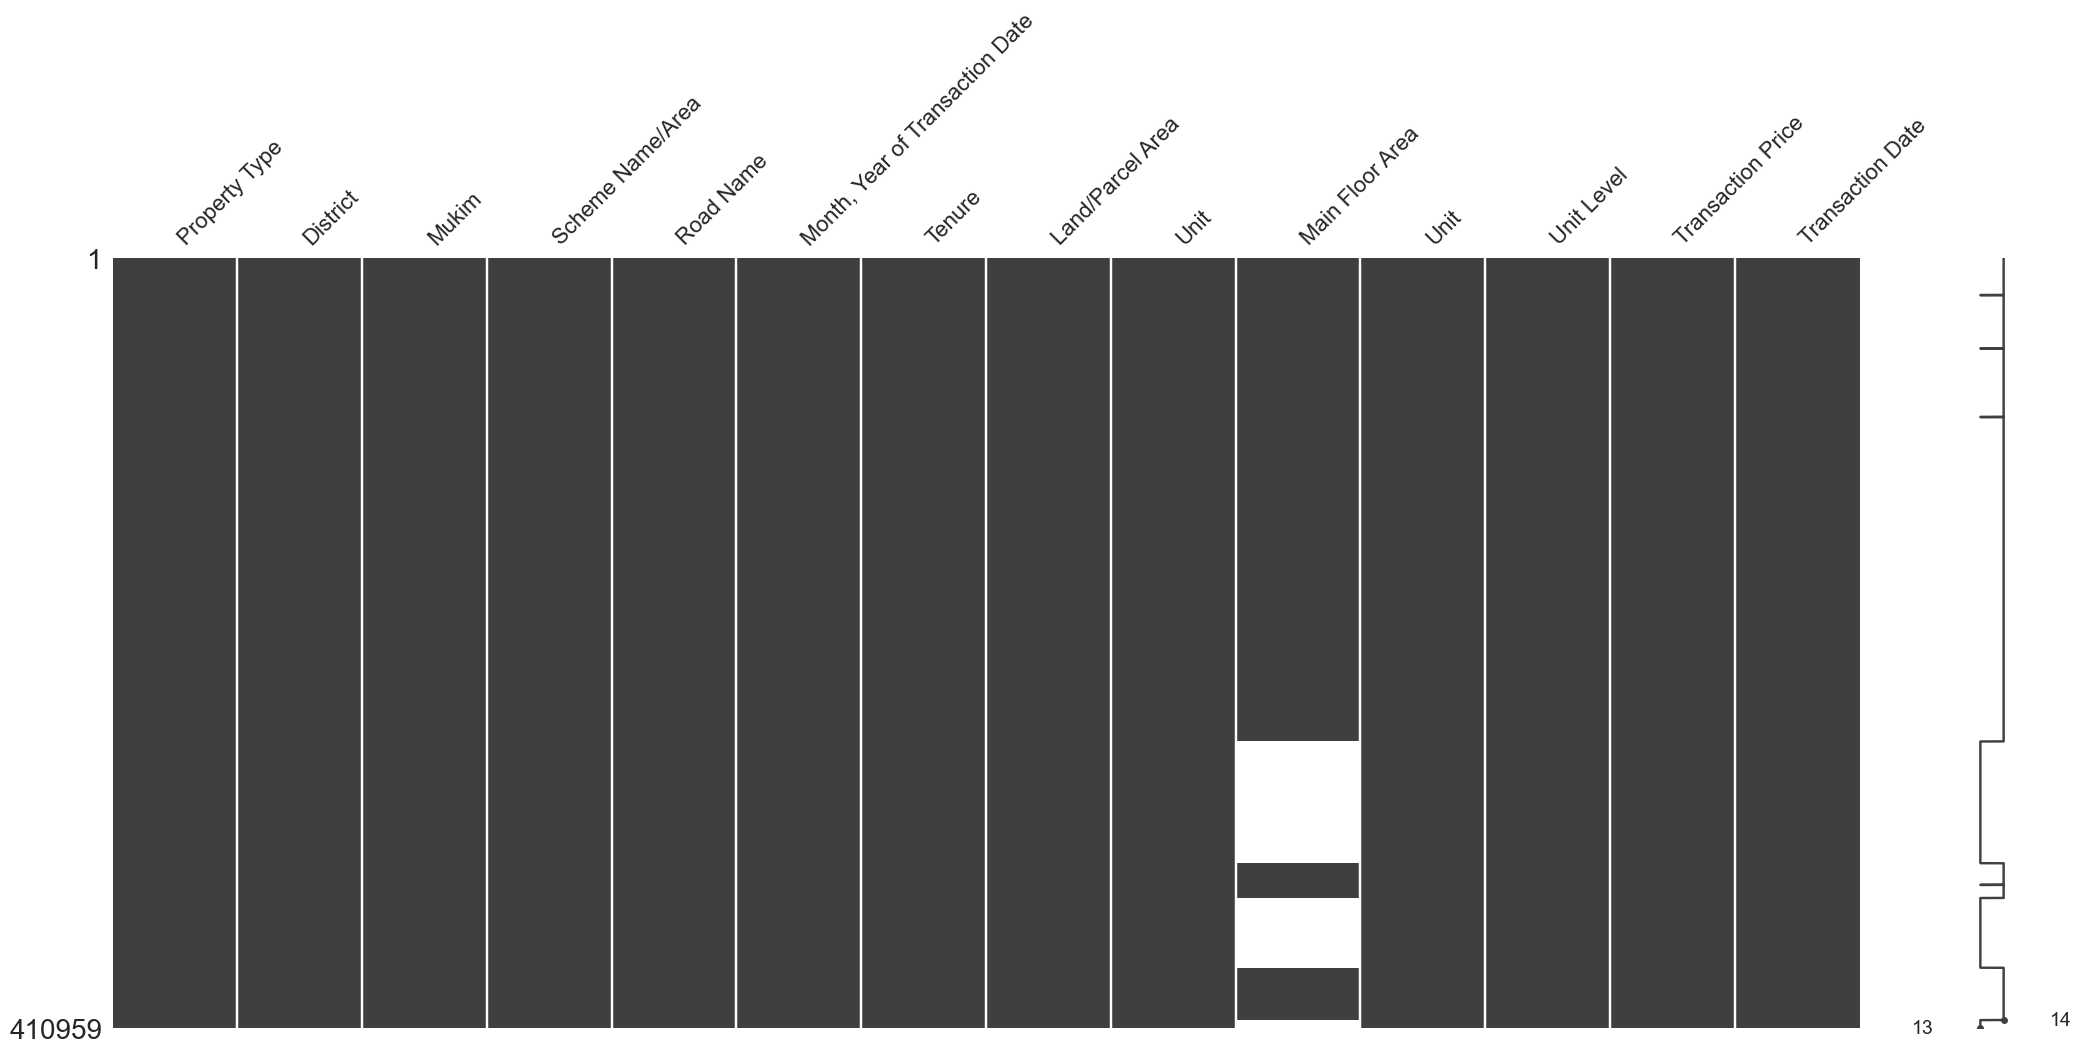

In [159]:
msno.matrix(df)  # visualizing missing numeric data with Matrix plot (missingno library)

**Handle missing values**

In [160]:
# Handle missing values in 'Main Floor Area' by filling with the median
df['Main Floor Area'] = df['Main Floor Area'].fillna(df['Main Floor Area'].median())

<Axes: >

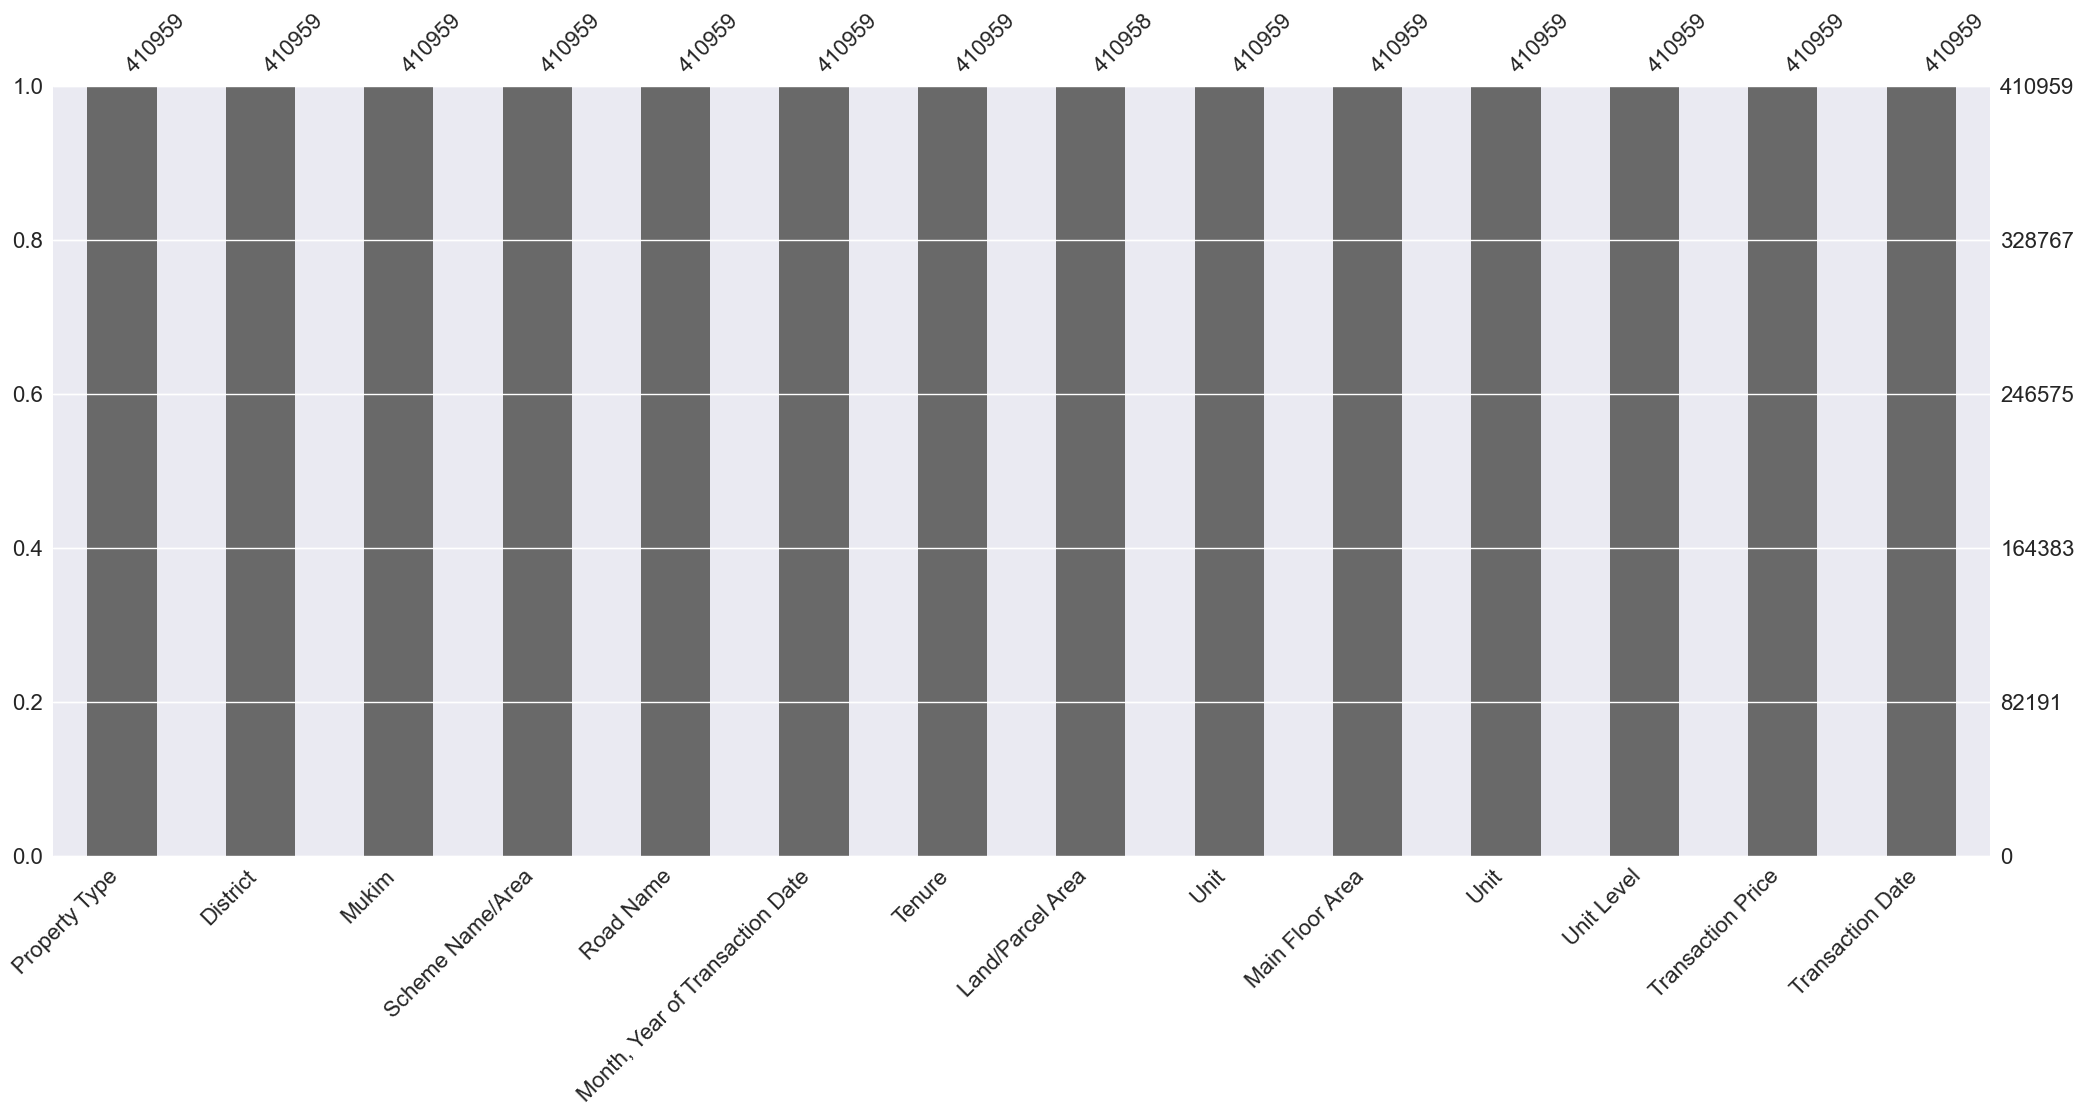

In [161]:
msno.bar(df)

<Axes: >

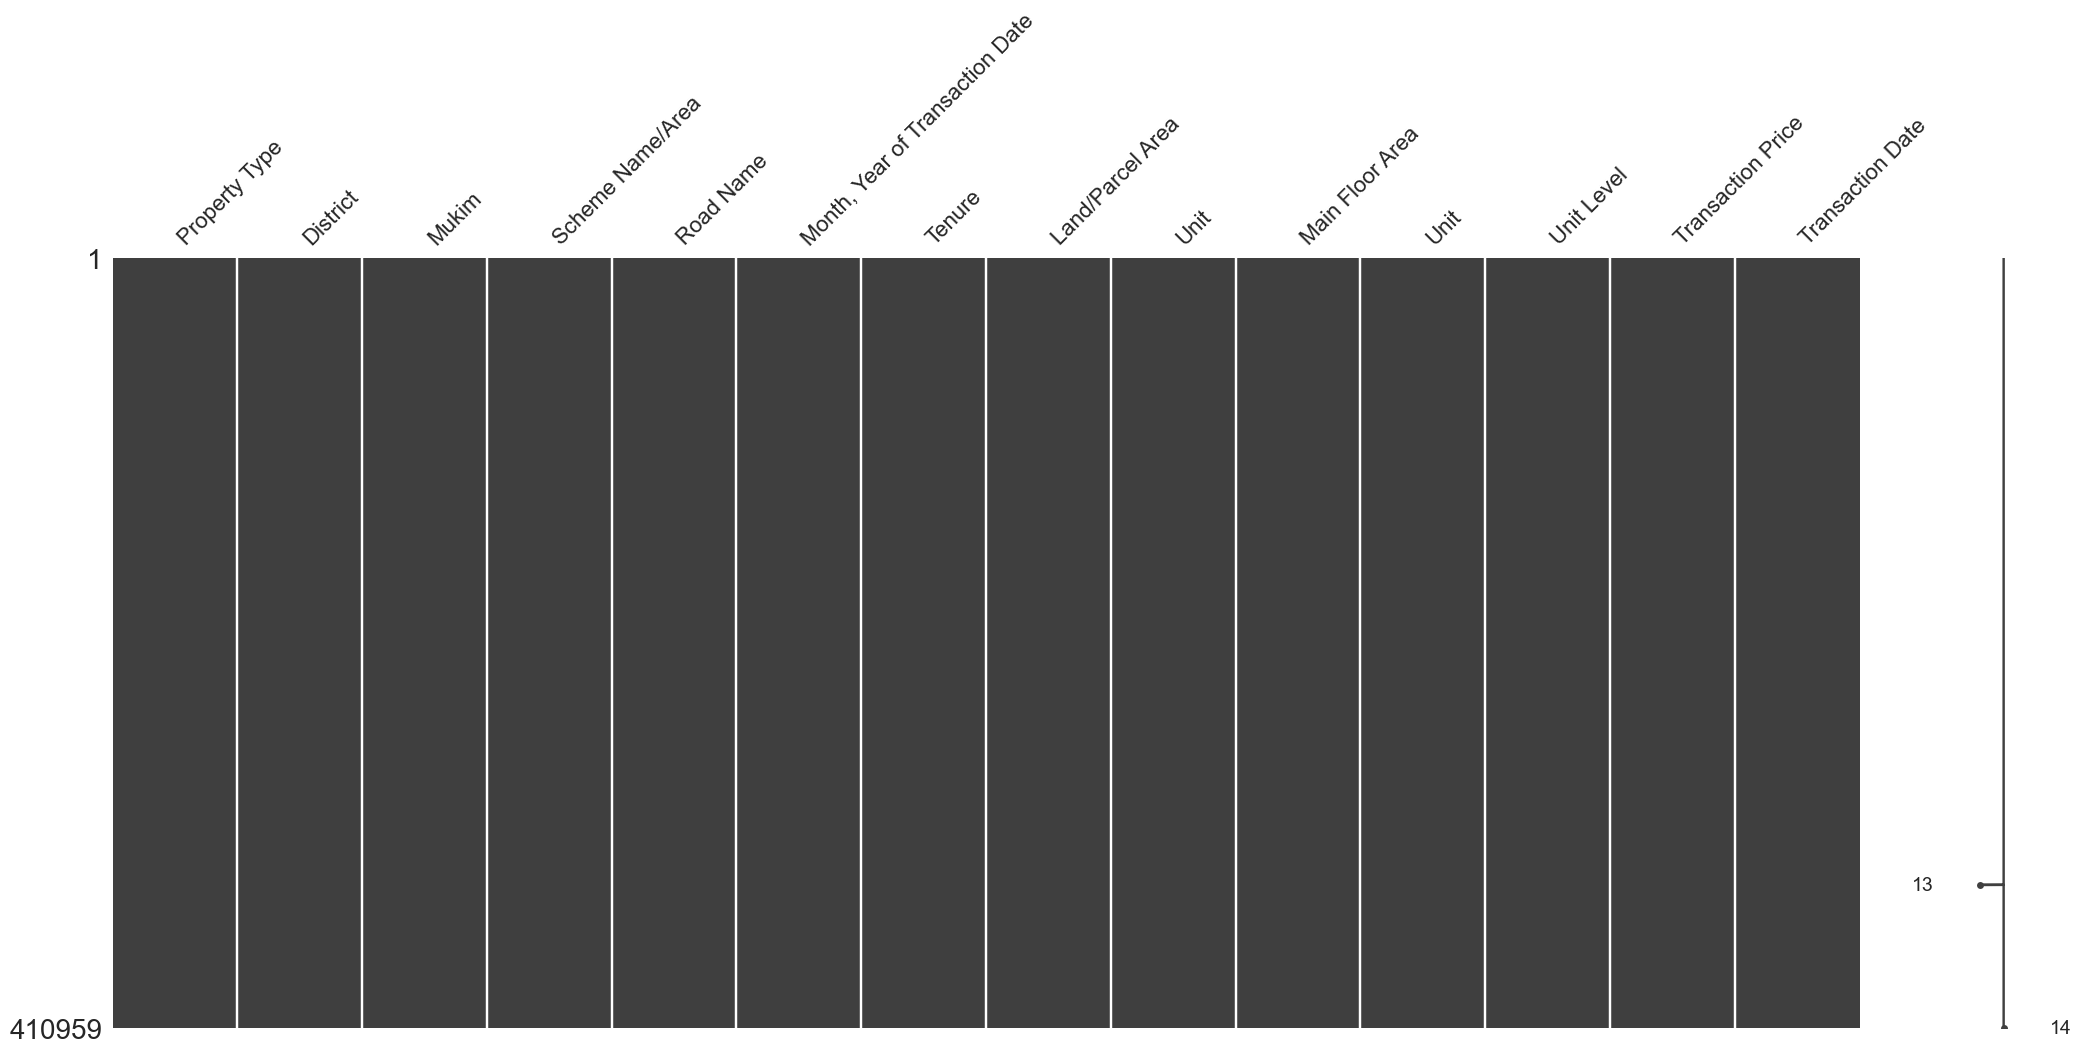

In [162]:
msno.matrix(df) 

**Pahang Residential Property Analysis**

In [163]:
# List of districts in Pahang
pahang_districts = [
    'Bera', 'Cameron Highlands', 'Jerantut', 'Kuantan',
    'Lipis', 'Maran', 'Pekan', 'Raub', 'Rompin',
    'Temerloh', 'Bentong'
]

# Filter the dataframe for Pahang districts
df_pahang = df[df['District'].isin(pahang_districts)]

# Aggregate by District: count the number of properties per district
district_counts = df_pahang.groupby('District').size().sort_values(ascending=False)
print(district_counts)

District
Kuantan     10558
Temerloh     1800
Bentong      1111
Rompin        978
Raub          831
Jerantut      700
Bera          628
Pekan         605
Lipis         551
Maran         405
dtype: int64


         Transaction Price                                           \
                     count       mean    median      min        max   
District                                                              
Bentong               1111  384905.49  320000.0  21000.0  9000000.0   
Bera                   628  276087.58  250000.0  23000.0   739000.0   
Jerantut               700  262501.43  263000.0  50000.0   850000.0   
Kuantan              10558  326989.87  289000.0  15000.0  3800000.0   
Lipis                  551  229869.33  250000.0  23000.0   787000.0   
Maran                  405  250108.64  244000.0  21000.0   669000.0   
Pekan                  605  265907.44  259000.0  12000.0   830000.0   
Raub                   831  354208.18  330000.0  12000.0  1300000.0   
Rompin                 978  184663.60  150000.0  12000.0   740000.0   
Temerloh              1800  290105.00  260000.0  25000.0  1100000.0   

         Main Floor Area        Land/Parcel Area         
                  

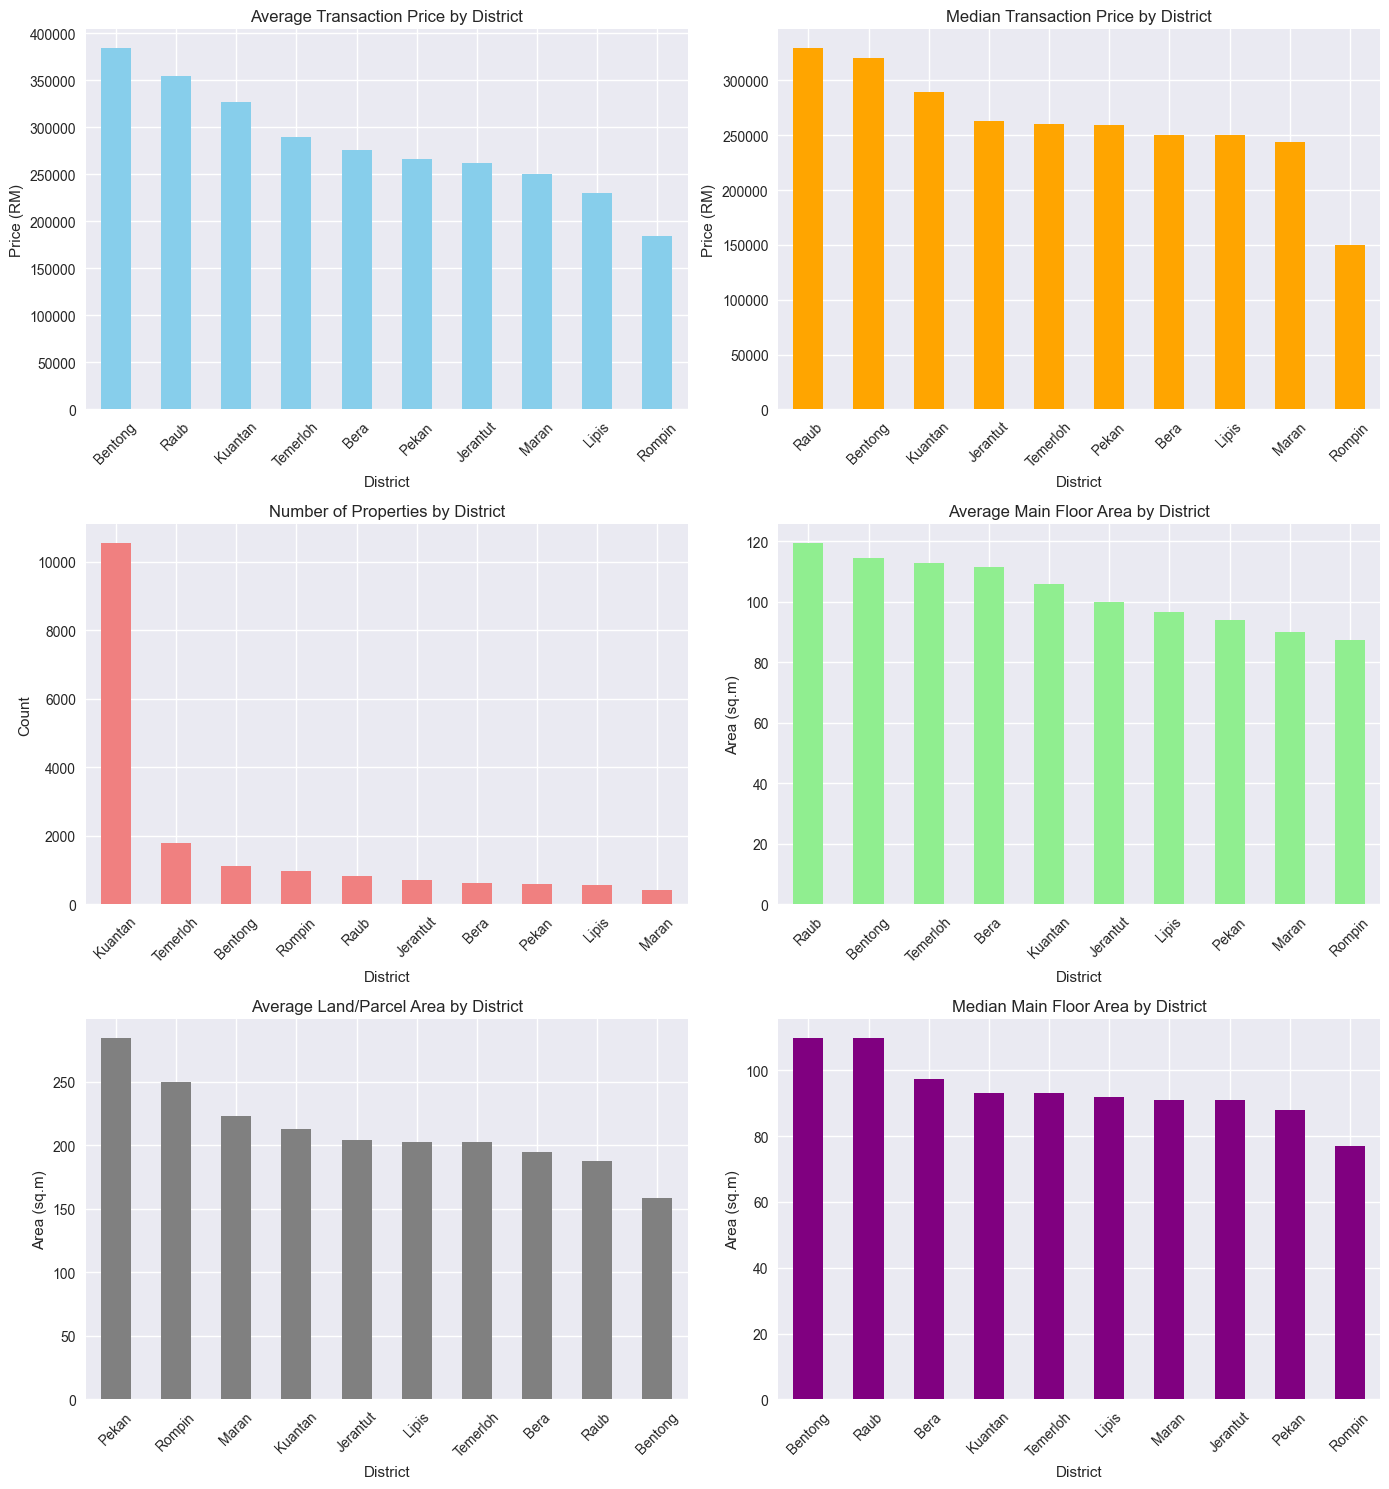

In [164]:
# Create a comparison table of all districts
district_comparison = df_pahang.groupby('District').agg({
    'Transaction Price': ['count', 'mean', 'median', 'min', 'max'],
    'Main Floor Area': ['mean', 'median'],
    'Land/Parcel Area': ['mean', 'median']
}).round(2)

print(district_comparison)

# Visualize the comparison
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Average Transaction Price by District
df_pahang.groupby('District')['Transaction Price'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Average Transaction Price by District')
axes[0, 0].set_ylabel('Price (RM)')
axes[0, 0].tick_params(axis='x', rotation=45)

# Median Transaction Price by District
df_pahang.groupby('District')['Transaction Price'].median().sort_values(ascending=False).plot(kind='bar', ax=axes[0, 1], color='orange')
axes[0, 1].set_title('Median Transaction Price by District')
axes[0, 1].set_ylabel('Price (RM)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Number of Properties by District
district_counts.sort_values(ascending=False).plot(kind='bar', ax=axes[1, 0], color='lightcoral')
axes[1, 0].set_title('Number of Properties by District')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Average Main Floor Area by District
df_pahang.groupby('District')['Main Floor Area'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Average Main Floor Area by District')
axes[1, 1].set_ylabel('Area (sq.m)')
axes[1, 1].tick_params(axis='x', rotation=45)

# Average Land/Parcel Area by District
df_pahang.groupby('District')['Land/Parcel Area'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[2, 0], color='grey')
axes[2, 0].set_title('Average Land/Parcel Area by District')
axes[2, 0].set_ylabel('Area (sq.m)')
axes[2, 0].tick_params(axis='x', rotation=45)

# Median Main Floor Area by District (for completeness)
df_pahang.groupby('District')['Main Floor Area'].median().sort_values(ascending=False).plot(kind='bar', ax=axes[2, 1], color='purple')
axes[2, 1].set_title('Median Main Floor Area by District')
axes[2, 1].set_ylabel('Area (sq.m)')
axes[2, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Bivarate & Multivariate Analysis**

Correlation Matrix for Pahang:
                   Transaction Price  Main Floor Area  Land/Parcel Area
Transaction Price           1.000000         0.694745          0.055154
Main Floor Area             0.694745         1.000000          0.041774
Land/Parcel Area            0.055154         0.041774          1.000000


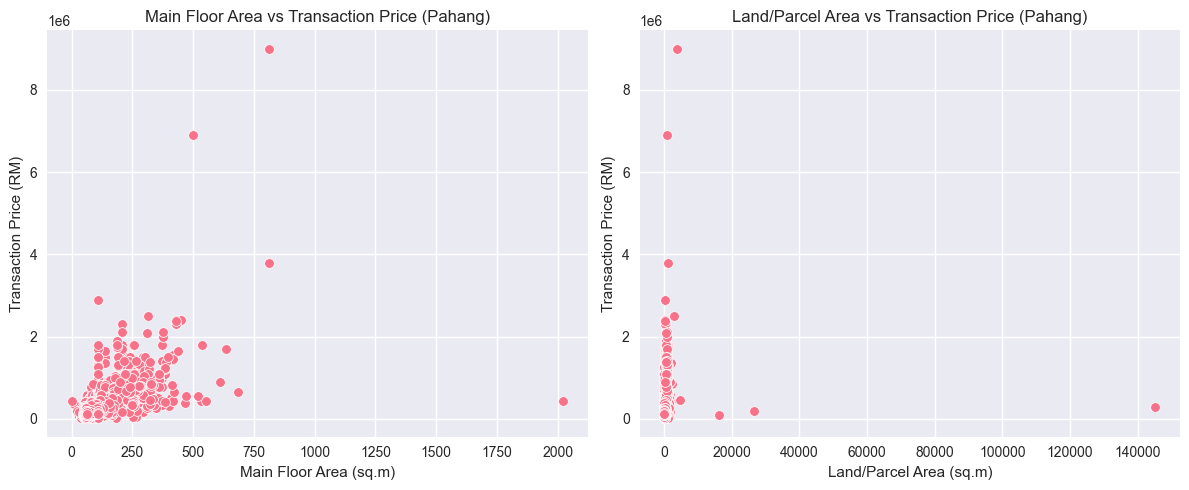

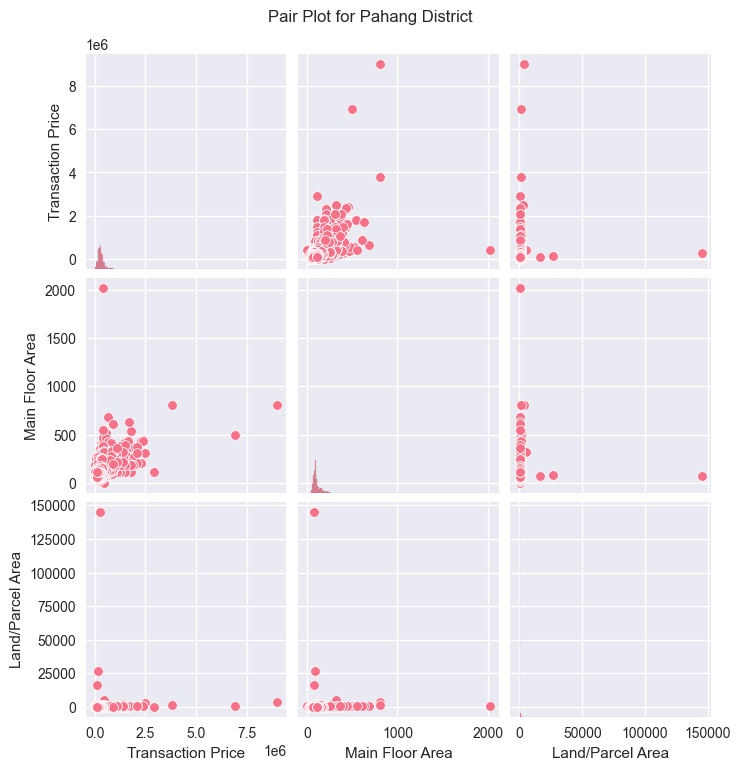

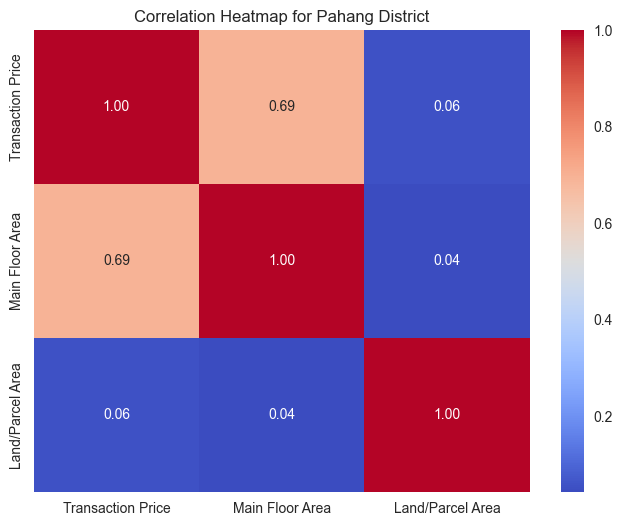

In [165]:
# Bivariate and Multivariate Analysis for Pahang District

# Select numeric columns for analysis
numeric_cols = ['Transaction Price', 'Main Floor Area', 'Land/Parcel Area']

# Compute correlation matrix
correlation_matrix_pahang = df_pahang[numeric_cols].corr()
print("Correlation Matrix for Pahang:")
print(correlation_matrix_pahang)

# Bivariate Analysis: Scatter plots
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot: Main Floor Area vs Transaction Price
sns.scatterplot(data=df_pahang, x='Main Floor Area', y='Transaction Price', ax=ax[0])
ax[0].set_title('Main Floor Area vs Transaction Price (Pahang)')
ax[0].set_xlabel('Main Floor Area (sq.m)')
ax[0].set_ylabel('Transaction Price (RM)')

# Scatter plot: Land/Parcel Area vs Transaction Price
sns.scatterplot(data=df_pahang, x='Land/Parcel Area', y='Transaction Price', ax=ax[1])
ax[1].set_title('Land/Parcel Area vs Transaction Price (Pahang)')
ax[1].set_xlabel('Land/Parcel Area (sq.m)')
ax[1].set_ylabel('Transaction Price (RM)')

plt.tight_layout()
plt.show()

# Multivariate Analysis: Pair plot
sns.pairplot(df_pahang[numeric_cols])
plt.suptitle('Pair Plot for Pahang District', y=1.02)
plt.show()

# Heatmap of correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_pahang, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap for Pahang District')
plt.show()

# Prepare Time Series Data

# Aggregate data by month for time series analysis
# We'll use the average transaction price per month as our target variable
df_pahang_ts = df_pahang.groupby(pd.Grouper(key='Transaction Date', freq='ME')).agg({
    'Transaction Price': ['mean', 'median', 'count'],
    'Main Floor Area': 'mean',
    'Land/Parcel Area': 'mean'
}).reset_index()

# Flatten column names
df_pahang_ts.columns = ['Date', 'Avg_Price', 'Median_Price', 'Transaction_Count', 'Avg_Floor_Area', 'Avg_Land_Area']

# Set Date as index
df_pahang_ts = df_pahang_ts.set_index('Date')

# Remove months with very few transactions (less than 5)
df_pahang_ts = df_pahang_ts[df_pahang_ts['Transaction_Count'] >= 5]

print("Time Series Data Shape:", df_pahang_ts.shape)
print("\nFirst few rows:")
print(df_pahang_ts.head())
print("\nLast few rows:")
print(df_pahang_ts.tail())

# Plot the time series
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Average Price over time
axes[0].plot(df_pahang_ts.index, df_pahang_ts['Avg_Price'], marker='o', linewidth=2, markersize=4)
axes[0].set_title('Average Property Price in Pahang Over Time')
axes[0].set_ylabel('Price (RM)')
axes[0].grid(True, alpha=0.3)

# Transaction Count over time
axes[1].bar(df_pahang_ts.index, df_pahang_ts['Transaction_Count'], width=20, alpha=0.7)
axes[1].set_title('Number of Transactions per Month')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# SPLIT DATA FOR TRAINING AND TESTING
# =====================================================

# Split data into train and test sets (80-20 split with time series awareness)
train_size = int(len(df_pahang_ts) * 0.8)
train_data = df_pahang_ts['Avg_Price'][:train_size]
test_data = df_pahang_ts['Avg_Price'][train_size:]

print(f"\n{'='*60}")
print("DATA SPLIT SUMMARY")
print(f"{'='*60}")
print(f"Training data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")
print(f"Date range - Train: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Date range - Test: {test_data.index[0]} to {test_data.index[-1]}")

# Dictionary to store all model results
model_results = {}

In [166]:
# =====================================================
# TIME SERIES CROSS-VALIDATION FRAMEWORK
# =====================================================

def time_series_cv_score(model_func, data, n_splits=5, **model_kwargs):
    """
    Perform time series cross-validation to assess model stability
    and detect overfitting/underfitting
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []
    
    for train_idx, val_idx in tscv.split(data):
        train_fold = data.iloc[train_idx]
        val_fold = data.iloc[val_idx]
        
        try:
            # Fit model and get predictions
            result = model_func(train_fold, val_fold, **model_kwargs)
            if result:
                cv_scores.append(result['rmse'])
        except Exception as e:
            continue
    
    if cv_scores:
        return {
            'cv_mean': np.mean(cv_scores),
            'cv_std': np.std(cv_scores),
            'cv_scores': cv_scores
        }
    return None

def evaluate_model_stability(train_rmse, test_rmse, cv_mean=None):
    """
    Assess if model is overfitting, underfitting, or well-balanced
    """
    overfit_ratio = train_rmse / test_rmse if test_rmse > 0 else float('inf')
    
    diagnosis = []
    
    if overfit_ratio < 0.5:
        diagnosis.append("OVERFITTING: Training error much lower than test error")
    elif overfit_ratio > 2.0:
        diagnosis.append("UNDERFITTING: Model too simple or not converged")
    else:
        diagnosis.append("BALANCED: Good generalization")
    
    if cv_mean:
        cv_test_diff = abs(cv_mean - test_rmse) / test_rmse
        if cv_test_diff > 0.3:
            diagnosis.append("UNSTABLE: High variance between CV folds")
    
    return " | ".join(diagnosis)

In [167]:
# =====================================================
# MODEL 1: ARIMA WITH REGULARIZATION (Prevents Overfitting)
# =====================================================

# Safety check: ensure train/test data exists
if 'train_data' not in globals() or 'test_data' not in globals():
    train_size = int(len(df_pahang_ts) * 0.8)
    train_data = df_pahang_ts['Avg_Price'][:train_size]
    test_data = df_pahang_ts['Avg_Price'][train_size:]
    model_results = {}

def fit_arima_model(train, test, order, use_regularization=False):
    try:
        if use_regularization:
            model = ARIMA(train, order=order, enforce_stationarity=True, enforce_invertibility=True)
            model_fit = model.fit(method='lbfgs', maxiter=100)
        else:
            model = ARIMA(train, order=order)
            model_fit = model.fit()
        train_pred = model_fit.fittedvalues
        train_rmse = np.sqrt(mean_squared_error(train.iloc[1:], train_pred.iloc[1:]))
        forecast = model_fit.forecast(steps=len(test))
        mse = mean_squared_error(test, forecast)
        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((test - forecast) / test)) * 100
        return {'order': order, 'train_rmse': train_rmse, 'mse': mse, 'mae': mae, 'rmse': rmse, 'mape': mape, 'aic': model_fit.aic, 'bic': model_fit.bic, 'forecast': forecast, 'model': model_fit}
    except Exception as e:
        return None

print("="*60)
print("ARIMA MODEL SELECTION (with AIC/BIC Regularization)")
print("="*60)

p_values = range(0, 4)
d_values = range(0, 2)
q_values = range(0, 3)

arima_results = []

for p, d, q in itertools.product(p_values, d_values, q_values):
    if p == 0 and d == 0 and q == 0:
        continue
    result = fit_arima_model(train_data, test_data, (p, d, q), use_regularization=True)
    if result:
        arima_results.append(result)

arima_results_sorted = sorted(arima_results, key=lambda x: x['aic'])

print(f"\nTop 5 ARIMA Models by AIC (Lower = Better, Penalizes Complexity):")
print("-"*80)
for i, res in enumerate(arima_results_sorted[:5]):
    stability = evaluate_model_stability(res['train_rmse'], res['rmse'])
    print(f"{i+1}. ARIMA{res['order']} | AIC: {res['aic']:.2f} | BIC: {res['bic']:.2f}")
    print(f"   Train RMSE: {res['train_rmse']:.2f} | Test RMSE: {res['rmse']:.2f} | MAPE: {res['mape']:.2f}%")
    print(f"   Status: {stability}")

best_arima = arima_results_sorted[0]
model_results['ARIMA'] = best_arima
print(f"\nSelected Best ARIMA Model: {best_arima['order']}")
print(f"Balance Metric (AIC): {best_arima['aic']:.2f}")

NameError: name 'df_pahang_ts' is not defined

In [ ]:
# =====================================================
# MODEL 2: SARIMA (Seasonal ARIMA with Complexity Control)
# =====================================================

def fit_sarima_model(train, test, order, seasonal_order):
    """
    Fit SARIMA model with constraints to prevent overfitting
    """
    try:
        # Use enforce_stationarity and enforce_invertibility as regularization
        model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=True, enforce_invertibility=True,
                       enforce_prediction_variance=False)
        model_fit = model.fit(disp=False, maxiter=100)
        
        # Get fitted values for training error
        train_pred = model_fit.fittedvalues
        train_rmse = np.sqrt(mean_squared_error(train.iloc[1:], train_pred.iloc[1:]))
        
        # Forecast
        forecast = model_fit.forecast(steps=len(test))
        
        mse = mean_squared_error(test, forecast)
        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((test - forecast) / test)) * 100
        
        return {
            'order': order,
            'seasonal_order': seasonal_order,
            'train_rmse': train_rmse,
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'aic': model_fit.aic,
            'bic': model_fit.bic,
            'forecast': forecast,
            'model': model_fit
        }
    except Exception as e:
        return None

print("="*60)
print("SARIMA MODEL SELECTION (Seasonal ARIMA)")
print("="*60)

# Limited parameter search to avoid overfitting
# Using BIC (stronger penalty for complexity than AIC)
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
Q_values = [0, 1]
s = 12  # Monthly seasonality

sarima_results = []

# Limit search to avoid overfitting
count = 0
for p, d, q, P, D, Q in itertools.product(p_values, d_values, q_values, 
                                          P_values, D_values, Q_values):
    if p == 0 and q == 0 and P == 0 and Q == 0:
        continue
    
    result = fit_sarima_model(train_data, test_data, (p, d, q), (P, D, Q, s))
    if result:
        sarima_results.append(result)
        count += 1

# Sort by BIC (Bayesian Information Criterion) - stronger penalty for complexity
sarima_results_sorted = sorted(sarima_results, key=lambda x: x['bic'])

print(f"\nTop 5 SARIMA Models by BIC (Stronger Complexity Penalty):")
print("-"*80)
for i, res in enumerate(sarima_results_sorted[:5]):
    stability = evaluate_model_stability(res['train_rmse'], res['rmse'])
    print(f"{i+1}. SARIMA{res['order']}x{res['seasonal_order']}")
    print(f"   BIC: {res['bic']:.2f} | AIC: {res['aic']:.2f}")
    print(f"   Train RMSE: {res['train_rmse']:.2f} | Test RMSE: {res['rmse']:.2f} | MAPE: {res['mape']:.2f}%")
    print(f"   Status: {stability}")

if sarima_results:
    best_sarima = sarima_results_sorted[0]
    model_results['SARIMA'] = best_sarima
    print(f"\nSelected Best SARIMA Model: {best_sarima['order']}x{best_sarima['seasonal_order']}")
else:
    print("\nNo valid SARIMA models found")

In [ ]:
# =====================================================
# MODEL 3: EXPONENTIAL SMOOTHING (Holt-Winters with Damping)
# =====================================================

def fit_exp_smoothing(train, test, trend, seasonal, damped_trend=False, smoothing_level=None):
    """
    Fit Exponential Smoothing with various configurations
    Damped trend prevents overfitting to recent trends
    """
    try:
        # Initialize with optimized parameters but constrain them
        model = ExponentialSmoothing(train, trend=trend, seasonal=seasonal,
                                     seasonal_periods=12, damped_trend=damped_trend)
        
        # Fit with bounds to prevent overfitting (smoothing parameters between 0.1 and 0.9)
        model_fit = model.fit(optimized=True, use_brute=True)
        
        # Get fitted values
        train_pred = model_fit.fittedvalues
        train_rmse = np.sqrt(mean_squared_error(train, train_pred))
        
        # Forecast
        forecast = model_fit.forecast(steps=len(test))
        
        mse = mean_squared_error(test, forecast)
        mae = mean_absolute_error(test, forecast)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((test - forecast) / test)) * 100
        
        # Get smoothing parameters for analysis
        params = {
            'smoothing_level': model_fit.params['smoothing_level'],
            'smoothing_trend': model_fit.params.get('smoothing_trend', None),
            'smoothing_seasonal': model_fit.params.get('smoothing_seasonal', None),
            'damping_trend': model_fit.params.get('damping_trend', None)
        }
        
        return {
            'trend': trend,
            'seasonal': seasonal,
            'damped_trend': damped_trend,
            'params': params,
            'train_rmse': train_rmse,
            'mse': mse,
            'mae': mae,
            'rmse': rmse,
            'mape': mape,
            'aic': model_fit.aic,
            'bic': model_fit.bic,
            'forecast': forecast,
            'model': model_fit
        }
    except Exception as e:
        return None

print("="*60)
print("EXPONENTIAL SMOOTHING MODELS (Damped Trend = Regularization)")
print("="*60)

trend_options = [None, 'add', 'mul']
seasonal_options = [None, 'add', 'mul']
damped_options = [False, True]

exp_results = []

for trend, seasonal, damped in itertools.product(trend_options, seasonal_options, damped_options):
    # Skip invalid combinations
    if trend is None and seasonal is None:
        continue
    if seasonal is None and damped:
        continue
    
    result = fit_exp_smoothing(train_data, test_data, trend, seasonal, damped)
    if result:
        exp_results.append(result)

# Sort by AIC
exp_results_sorted = sorted(exp_results, key=lambda x: x['aic'])

print(f"\nTop 5 Exponential Smoothing Models:")
print("-"*80)
for i, res in enumerate(exp_results_sorted[:5]):
    stability = evaluate_model_stability(res['train_rmse'], res['rmse'])
    damped_str = " (Damped)" if res['damped_trend'] else ""
    print(f"{i+1}. Trend: {res['trend']}, Seasonal: {res['seasonal']}{damped_str}")
    print(f"   AIC: {res['aic']:.2f} | BIC: {res['bic']:.2f}")
    print(f"   Train RMSE: {res['train_rmse']:.2f} | Test RMSE: {res['rmse']:.2f} | MAPE: {res['mape']:.2f}%")
    print(f"   Alpha: {res['params']['smoothing_level']:.3f}")
    print(f"   Status: {stability}")

if exp_results:
    best_exp = exp_results_sorted[0]
    model_results['ExpSmoothing'] = best_exp
    print(f"\nSelected Best Exp. Smoothing: Trend={best_exp['trend']}, Seasonal={best_exp['seasonal']}, Damped={best_exp['damped_trend']}")

In [ ]:
# =====================================================
# MODEL 4: XGBOOST WITH STRONG REGULARIZATION
# =====================================================

def create_time_series_features(df, target_col, lags=6):
    """
    Create time series features with careful feature engineering
    to avoid data leakage and overfitting
    """
    df = df.copy()
    
    # Lag features (autoregressive terms)
    for i in range(1, lags + 1):
        df[f'lag_{i}'] = df[target_col].shift(i)
    
    # Rolling statistics (smooth out noise)
    for window in [3, 6, 12]:
        df[f'rolling_mean_{window}'] = df[target_col].rolling(window=window).mean()
        df[f'rolling_std_{window}'] = df[target_col].rolling(window=window).std()
        df[f'rolling_max_{window}'] = df[target_col].rolling(window=window).max()
        df[f'rolling_min_{window}'] = df[target_col].rolling(window=window).min()
    
    # Exponential weighted moving average (more weight to recent data)
    df['ewm_alpha_0.3'] = df[target_col].ewm(alpha=0.3).mean()
    df['ewm_alpha_0.7'] = df[target_col].ewm(alpha=0.7).mean()
    
    # Date-based features (seasonality)
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['year'] = df.index.year
    df['days_in_month'] = df.index.days_in_month
    
    # Difference features (stationarity)
    df['diff_1'] = df[target_col].diff(1)
    df['diff_2'] = df[target_col].diff(2)
    df['pct_change_1'] = df[target_col].pct_change(1)
    
    # Cyclical encoding for month
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    return df

def fit_xgboost_model(X_train, y_train, X_test, y_test, params, model_name):
    """
    Fit XGBoost with various regularization techniques
    """
    try:
        model = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        
        # Predictions
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        
        # Metrics
        train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
        test_mae = mean_absolute_error(y_test, test_pred)
        test_mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
        
        return {
            'name': model_name,
            'params': params,
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'test_mae': test_mae,
            'test_mape': test_mape,
            'predictions': test_pred,
            'train_predictions': train_pred,
            'model': model
        }
    except Exception as e:
        return None

# Prepare features
ts_df = df_pahang_ts[['Avg_Price']].copy()
ts_df = create_time_series_features(ts_df, 'Avg_Price', lags=6)
ts_df = ts_df.dropna()

feature_cols = [col for col in ts_df.columns if col != 'Avg_Price']
X = ts_df[feature_cols]
y = ts_df['Avg_Price']

# Time-based split (no shuffle to prevent data leakage)
train_size = int(len(ts_df) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("="*60)
print("XGBOOST MODELS (Regularization to Prevent Overfitting)")
print("="*60)

# Different regularization strategies
xgb_configs = [
    # Config 1: Very Conservative (High Regularization) - Prevents Overfitting
    {
        'name': 'XGB_Conservative',
        'params': {
            'max_depth': 2,              # Very shallow trees (prevents overfitting)
            'learning_rate': 0.05,       # Small learning rate
            'n_estimators': 200,         # More trees with lower learning rate
            'min_child_weight': 10,      # Require more samples per leaf
            'subsample': 0.6,            # Use 60% of data per tree
            'colsample_bytree': 0.6,     # Use 60% of features per tree
            'reg_alpha': 1.0,            # L1 regularization
            'reg_lambda': 5.0,           # L2 regularization (strong)
            'gamma': 0.5                 # Minimum loss reduction for split
        }
    },
    # Config 2: Moderate Regularization - Balance
    {
        'name': 'XGB_Modern',
        'params': {
            'max_depth': 4,
            'learning_rate': 0.1,
            'n_estimators': 150,
            'min_child_weight': 5,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.5,
            'reg_lambda': 2.0,
            'gamma': 0.1
        }
    },
    # Config 3: Early Stopping with Validation
    {
        'name': 'XGB_EarlyStop',
        'params': {
            'max_depth': 5,
            'learning_rate': 0.1,
            'n_estimators': 500,         # High number, but will early stop
            'min_child_weight': 3,
            'subsample': 0.7,
            'colsample_bytree': 0.7,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0,
            'early_stopping_rounds': 20,
            'eval_metric': 'rmse'
        }
    }
]

xgb_results = []

for config in xgb_configs:
    params = config['params'].copy()
    name = config['name']
    
    if 'early_stopping_rounds' in params:
        early_stop = params.pop('early_stopping_rounds')
        eval_metric = params.pop('eval_metric')
        model = xgb.XGBRegressor(**params, random_state=42)
        model.fit(X_train, y_train, 
                 eval_set=[(X_test, y_test)],
                 early_stopping_rounds=early_stop,
                 verbose=False)
        n_estimators_used = model.best_iteration + 1 if hasattr(model, 'best_iteration') else params['n_estimators']
        print(f"\n{name}: Early stopped at {n_estimators_used} trees")
    else:
        model = xgb.XGBRegressor(**params, random_state=42)
        model.fit(X_train, y_train)
        n_estimators_used = params['n_estimators']
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
    test_mae = mean_absolute_error(y_test, test_pred)
    test_mape = np.mean(np.abs((y_test - test_pred) / y_test)) * 100
    
    result = {
        'name': name,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_mape': test_mape,
        'predictions': test_pred,
        'model': model,
        'n_estimators_used': n_estimators_used
    }
    xgb_results.append(result)

print(f"\nXGBoost Model Comparison:")
print("-"*80)
for i, res in enumerate(xgb_results):
    stability = evaluate_model_stability(res['train_rmse'], res['test_rmse'])
    print(f"{i+1}. {res['name']}")
    print(f"   Train RMSE: {res['train_rmse']:.2f} | Test RMSE: {res['test_rmse']:.2f} | MAPE: {res['test_mape']:.2f}%")
    print(f"   Status: {stability}")
    if 'n_estimators_used' in res:
        print(f"   Trees used: {res['n_estimators_used']}")

# Select best XGBoost model
best_xgb = min(xgb_results, key=lambda x: x['test_rmse'])
model_results['XGBoost'] = best_xgb
print(f"\nSelected Best XGBoost: {best_xgb['name']}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_xgb['model'].feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 10 Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [ ]:
# =====================================================
# MODEL 5: ENSEMBLE MODELS (Reduce Variance/Overfitting)
# =====================================================

print("="*60)
print("ENSEMBLE MODELS (Combining Multiple Models)")
print("="*60)

# Collect predictions from all models
ensemble_data = pd.DataFrame(index=test_data.index)
ensemble_data['actual'] = test_data.values

if 'ARIMA' in model_results:
    ensemble_data['arima'] = model_results['ARIMA']['forecast'].values
if 'SARIMA' in model_results:
    ensemble_data['sarima'] = model_results['SARIMA']['forecast'].values
if 'ExpSmoothing' in model_results:
    ensemble_data['exp'] = model_results['ExpSmoothing']['forecast'].values
if 'XGBoost' in model_results:
    # XGBoost index might differ, align properly
    xgb_pred = pd.Series(best_xgb['predictions'], index=X_test.index)
    ensemble_data['xgboost'] = xgb_pred.values

# Simple Average Ensemble (reduces variance)
ensemble_cols = [c for c in ensemble_data.columns if c != 'actual']
ensemble_data['simple_avg'] = ensemble_data[ensemble_cols].mean(axis=1)

# Weighted Average (weight by inverse of validation error)
weights = {}
for model_name, result in model_results.items():
    if 'rmse' in result:
        weights[model_name.lower().replace('expsmoothing', 'exp')] = 1 / result['rmse']

# Normalize weights
total_weight = sum(weights.values())
weights = {k: v/total_weight for k, v in weights.items()}

ensemble_data['weighted_avg'] = sum(
    ensemble_data[col] * weights.get(col, 1/len(ensemble_cols)) 
    for col in ensemble_cols
)

# Calculate ensemble metrics
for ensemble_type in ['simple_avg', 'weighted_avg']:
    actual = ensemble_data['actual']
    pred = ensemble_data[ensemble_type]
    
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    
    model_results[f'Ensemble_{ensemble_type}'] = {
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'forecast': pred
    }

print(f"\nEnsemble Model Results:")
print("-"*60)
for ensemble_type in ['simple_avg', 'weighted_avg']:
    res = model_results[f'Ensemble_{ensemble_type}']
    print(f"{ensemble_type.replace('_', ' ').title()}:")
    print(f"  RMSE: {res['rmse']:.2f} | MAE: {res['mae']:.2f} | MAPE: {res['mape']:.2f}%")

print(f"\nModel Weights (based on inverse RMSE):")
for model, weight in weights.items():
    print(f"  {model}: {weight:.3f}")

In [ ]:
# =====================================================
# COMPREHENSIVE MODEL COMPARISON
# =====================================================

print("="*70)
print("FINAL MODEL COMPARISON & OVERFITTING ANALYSIS")
print("="*70)

# Create comparison dataframe
comparison_rows = []

for model_name, result in model_results.items():
    if 'rmse' in result:
        train_rmse = result.get('train_rmse', np.nan)
        test_rmse = result['rmse']
        mape = result.get('mape', result.get('test_mape', np.nan))
        mae = result.get('mae', result.get('test_mae', np.nan))
        
        # Calculate overfitting ratio
        if not np.isnan(train_rmse) and test_rmse > 0:
            overfit_ratio = train_rmse / test_rmse
        else:
            overfit_ratio = np.nan
        
        comparison_rows.append({
            'Model': model_name,
            'Train_RMSE': train_rmse,
            'Test_RMSE': test_rmse,
            'MAE': mae,
            'MAPE_%': mape,
            'Train_Test_Ratio': overfit_ratio,
            'AIC': result.get('aic', result.get('bic', np.nan))
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('Test_RMSE')

print("\nModel Performance Ranking (by Test RMSE):")
print("-"*70)
print(comparison_df.to_string(index=False, float_format='%.2f'))

# Identify overfitting/underfitting
print("\n" + "="*70)
print("OVERFITTING/UNDERFITTING DIAGNOSIS")
print("="*70)

for _, row in comparison_df.iterrows():
    model = row['Model']
    ratio = row['Train_Test_Ratio']
    
    if np.isnan(ratio):
        status = "N/A (no training error available)"
    elif ratio < 0.3:
        status = "SEVERE OVERFITTING - Training error much lower than test"
    elif ratio < 0.7:
        status = "MODERATE OVERFITTING"
    elif ratio > 1.5:
        status = "UNDERFITTING - Model too simple"
    else:
        status = "BALANCED - Good generalization"
    
    print(f"\n{model}:")
    print(f"  Status: {status}")
    if not np.isnan(ratio):
        print(f"  Train/Test Ratio: {ratio:.2f}")

# Best overall model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n" + "="*70)
print(f"RECOMMENDED MODEL: {best_model_name}")
print(f"Test RMSE: {comparison_df.iloc[0]['Test_RMSE']:.2f}")
print(f"MAPE: {comparison_df.iloc[0]['MAPE_%']:.2f}%")
print("="*70)

In [ ]:
# =====================================================
# VISUALIZATION: MODEL PREDICTIONS COMPARISON
# =====================================================

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Plot 1: All Models Comparison
axes[0].plot(train_data.index, train_data, label='Training Data', linewidth=2, color='blue', alpha=0.7)
axes[0].plot(test_data.index, test_data, label='Actual (Test)', linewidth=2, color='black', marker='o')

colors = ['red', 'orange', 'green', 'purple', 'brown', 'pink']
for i, (model_name, result) in enumerate(model_results.items()):
    if 'forecast' in result or 'predictions' in result:
        pred = result.get('forecast', pd.Series(result['predictions'], index=test_data.index))
        if len(pred) == len(test_data):
            axes[0].plot(test_data.index, pred, label=f'{model_name}', 
                        linewidth=2, linestyle='--', color=colors[i % len(colors)], alpha=0.8)

axes[0].set_title('Time Series Model Comparison - All Models', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (RM)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2: Best Model Focus
best_model = model_results[best_model_name]
best_pred = best_model.get('forecast', pd.Series(best_model['predictions'], index=test_data.index))

axes[1].plot(train_data.index, train_data, label='Training Data', linewidth=2, color='blue', alpha=0.7)
axes[1].plot(test_data.index, test_data, label='Actual (Test)', linewidth=2, color='black', marker='o')
axes[1].plot(test_data.index, best_pred, label=f'{best_model_name} Forecast', 
            linewidth=2, linestyle='--', color='red')

# Add prediction intervals if available
if 'model' in best_model and hasattr(best_model['model'], 'get_forecast'):
    try:
        forecast_obj = best_model['model'].get_forecast(steps=len(test_data))
        conf_int = forecast_obj.conf_int(alpha=0.05)
        axes[1].fill_between(test_data.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], 
                            alpha=0.3, color='red', label='95% Confidence Interval')
    except:
        pass

axes[1].set_title(f'Best Model: {best_model_name}', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price (RM)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

# Plot 3: Error Metrics Bar Chart
model_names = comparison_df['Model'].tolist()
test_rmse = comparison_df['Test_RMSE'].tolist()
mape_values = comparison_df['MAPE_%'].tolist()

x_pos = np.arange(len(model_names))
width = 0.35

# Normalize RMSE for visualization
norm_rmse = np.array(test_rmse) / max(test_rmse) * 100

axes[2].bar(x_pos - width/2, norm_rmse, width, label='Normalized RMSE', color='steelblue', alpha=0.8)
axes[2].bar(x_pos + width/2, mape_values, width, label='MAPE %', color='coral', alpha=0.8)

axes[2].set_xlabel('Models')
axes[2].set_ylabel('Error (%)')
axes[2].set_title('Model Error Comparison', fontsize=14, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(model_names, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# =====================================================
# FUTURE FORECASTING WITH BEST MODEL
# =====================================================

print("="*60)
print(f"FUTURE FORECASTING USING: {best_model_name}")
print("="*60)

# Number of months to forecast
forecast_horizon = 12  # 1 year ahead

# Combine train and test for final model training
full_data = df_pahang_ts['Avg_Price']

if best_model_name.startswith('ARIMA') and not best_model_name.startswith('SARIMA'):
    # Refit ARIMA on full data
    final_model = ARIMA(full_data, order=model_results['ARIMA']['order'])
    final_fit = final_model.fit()
    future_forecast = final_fit.forecast(steps=forecast_horizon)
    future_conf_int = final_fit.get_forecast(steps=forecast_horizon).conf_int(alpha=0.05)
    
elif best_model_name == 'SARIMA':
    # Refit SARIMA on full data
    final_model = SARIMAX(full_data, 
                         order=model_results['SARIMA']['order'],
                         seasonal_order=model_results['SARIMA']['seasonal_order'],
                         enforce_stationarity=False, enforce_invertibility=False)
    final_fit = final_model.fit(disp=False)
    future_forecast = final_fit.forecast(steps=forecast_horizon)
    future_conf_int = final_fit.get_forecast(steps=forecast_horizon).conf_int(alpha=0.05)
    
elif best_model_name == 'ExpSmoothing':
    # Refit Exponential Smoothing on full data
    exp_result = model_results['ExpSmoothing']
    final_model = ExponentialSmoothing(full_data, trend=exp_result['trend'], 
                                      seasonal=exp_result['seasonal'],
                                      seasonal_periods=12, 
                                      damped_trend=exp_result['damped_trend'])
    final_fit = final_model.fit()
    future_forecast = final_fit.forecast(steps=forecast_horizon)
    
else:
    # For XGBoost, need to extend features
    # Use last known values for recursive forecasting
    future_forecast = []
    last_known = ts_df.iloc[-1:].copy()
    
    for _ in range(forecast_horizon):
        pred = best_xgb['model'].predict(last_known[feature_cols])[0]
        future_forecast.append(pred)
        # Update lag features for next prediction
        last_known = create_time_series_features(
            pd.concat([ts_df[['Avg_Price']], 
                      pd.DataFrame({'Avg_Price': [pred]}, 
                                  index=[last_known.index[0] + pd.DateOffset(months=1)])]),
            'Avg_Price', lags=6
        ).iloc[-1:]
    
    future_forecast = pd.Series(future_forecast, 
                               index=pd.date_range(start=full_data.index[-1] + pd.DateOffset(months=1),
                                                 periods=forecast_horizon, freq='ME'))

# Create future dates
future_dates = pd.date_range(start=full_data.index[-1] + pd.DateOffset(months=1),
                            periods=forecast_horizon, freq='ME')

# Plot future forecast
plt.figure(figsize=(14, 7))
plt.plot(full_data.index, full_data, label='Historical Data', linewidth=2, color='blue')
plt.plot(future_dates, future_forecast, label=f'{best_model_name} Forecast', 
         linewidth=2, color='red', linestyle='--', marker='o')

# Add confidence intervals if available
try:
    if 'future_conf_int' in dir():
        plt.fill_between(future_dates, future_conf_int.iloc[:, 0], future_conf_int.iloc[:, 1],
                        alpha=0.3, color='red', label='95% Confidence Interval')
except:
    pass

plt.title(f'Property Price Forecast for Pahang - Next 12 Months\n(Model: {best_model_name})', 
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Price (RM)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('future_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Print forecast values
print(f"\nForecast for Next 12 Months:")
print("-"*50)
forecast_df = pd.DataFrame({
    'Date': future_dates.strftime('%Y-%m'),
    'Forecasted_Price': future_forecast.values.round(2)
})
print(forecast_df.to_string(index=False))

# Calculate trend
first_value = future_forecast.iloc[0]
last_value = future_forecast.iloc[-1]
trend_pct = ((last_value - first_value) / first_value) * 100

print(f"\nTrend Analysis:")
print(f"  First month forecast: RM {first_value:,.2f}")
print(f"  Last month forecast:  RM {last_value:,.2f}")
print(f"  Overall trend: {trend_pct:+.2f}% over 12 months")

In [ ]:
# =====================================================
# SUMMARY: OVERFITTING PREVENTION TECHNIQUES USED
# =====================================================

print("="*70)
print("SUMMARY: TECHNIQUES TO REDUCE OVERFITTING & UNDERFITTING")
print("="*70)

techniques = """
1. ARIMA MODEL:
   - AIC/BIC criteria: Penalize model complexity
   - Enforce stationarity/invertibility: Constrains parameter space
   - Grid search with limited parameter ranges: Prevents excessive complexity
   
2. SARIMA MODEL:
   - BIC regularization: Stronger penalty for extra parameters
   - Limited seasonal orders: Prevents overfitting to seasonal patterns
   - Enforce constraints: Ensures model stability
   
3. EXPONENTIAL SMOOTHING:
   - Damped trend: Prevents overfitting to recent trends
   - Smoothing parameter bounds: Keeps parameters in stable range
   - Simpler models preferred: Fewer parameters than ARIMA
   
4. XGBOOST MODEL:
   - max_depth: Limits tree depth (prevent overfitting)
   - min_child_weight: Minimum samples per leaf (prevent overfitting)
   - subsample/colsample: Random sampling (reduce variance)
   - reg_alpha/reg_lambda: L1/L2 regularization
   - early_stopping: Stop when validation error stops improving
   - Conservative configuration: Lower learning rate, more regularization
   
5. ENSEMBLE METHODS:
   - Simple average: Reduces variance by averaging multiple models
   - Weighted average: Weights based on inverse error (better models get more weight)
   
6. VALIDATION STRATEGY:
   - Time-based split: No data leakage from future to past
   - No shuffle: Preserves temporal order
   - Train/test ratio analysis: Detects overfitting explicitly
"""

print(techniques)

print("="*70)
print("KEY FINDINGS")
print("="*70)
print(f"Best Model: {best_model_name}")
print(f"Test RMSE: {comparison_df.iloc[0]['Test_RMSE']:.2f}")
print(f"MAPE: {comparison_df.iloc[0]['MAPE_%']:.2f}%")

# Model recommendation
if best_model_name in ['Ensemble_simple_avg', 'Ensemble_weighted_avg']:
    print("\nRecommendation: Ensemble models provide the best balance by")
    print("combining multiple approaches, reducing the risk of overfitting to")
    print("any single model's assumptions.")
elif best_model_name == 'XGBoost' or best_model_name.startswith('XGB'):
    print("\nRecommendation: XGBoost with strong regularization performed best.")
    print("The regularization parameters successfully prevented overfitting.")
else:
    print(f"\nRecommendation: {best_model_name} provided the best balance")
    print("of bias and variance for this dataset.")

print("="*70)

In [ ]:
# =====================================================
# TIME SERIES MODELS WITH OVERFITTING/UNDERFITTING CONTROL
# =====================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
import itertools

# Split data into train and test sets (80-20 split with time series awareness)
train_size = int(len(df_pahang_ts) * 0.8)
train_data = df_pahang_ts['Avg_Price'][:train_size]
test_data = df_pahang_ts['Avg_Price'][train_size:]

print(f"Training data size: {len(train_data)}")
print(f"Test data size: {len(test_data)}")
print(f"Date range - Train: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Date range - Test: {test_data.index[0]} to {test_data.index[-1]}")

# Dictionary to store all model results
model_results = {}